# 🃏 BlackjackVAI — Entrenamiento Local v5

**Modelo:** YOLOv8m-seg (segmentación de instancias)  
**Dataset:** BlackjackVAI V4 + copias degradadas (x3 imágenes de entrenamiento)  
**GPU:** Local (RTX 4070 Laptop / cualquier CUDA)  
**Tracking:** MLflow  

### Mejoras respecto a v4
- **Fine-tuning desde `best.pt` v4**: ya sabe reconocer cartas a distancia
- **Augmentation de calidad de imagen** (nuevo en v5): para cada imagen de train se generan copias con blur gaussiano, blur de movimiento, ruido, compresión JPEG y baja iluminación — el modelo aprende a ser robusto con webcams de baja calidad
- **3× más datos de entrenamiento** sin etiquetar nada nuevo
- Mismo split 80/20, mismos parámetros geométricos agresivos de v4
- Reanuda automáticamente si el entreno se interrumpe (`RESUME = True`)

## 0. Configuración

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

MLFLOW_EXPERIMENT = "blackjackvai-v5"
MLFLOW_DB = "sqlite:///" + os.path.abspath("mlflow.db")
os.environ["MLFLOW_TRACKING_URI"]    = MLFLOW_DB
os.environ["MLFLOW_EXPERIMENT_NAME"] = MLFLOW_EXPERIMENT

ROBOFLOW_API_KEY   = os.environ["ROBOFLOW_API_KEY"]
ROBOFLOW_WORKSPACE = "javiers-workspace-q8mnr"
ROBOFLOW_PROJECT   = "blackjackvai"
ROBOFLOW_VERSION   = 4

from pathlib import Path
BASE_DIR    = Path(".").resolve()
DATASET_DIR = BASE_DIR / f"BlackjackVAI-{ROBOFLOW_VERSION}"
WORKDIR     = BASE_DIR / "training_runs"
MODELS_DIR  = BASE_DIR / "models"

RUN_NAME    = "yolo8m_seg_v5"
MODEL_BASE  = "models/best.pt"
EPOCHS      = 80
IMGSZ       = 640
BATCH       = 8
PATIENCE    = 20
SEED        = 42
SAVE_PERIOD = 10
RESUME      = True

DATA_YAML = DATASET_DIR / "data.yaml"
RUN_DIR   = WORKDIR / "runs" / RUN_NAME
BEST_PT   = RUN_DIR / "weights" / "best.pt"
LAST_PT   = RUN_DIR / "weights" / "last.pt"

WORKDIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset dir         : {DATASET_DIR}")
print(f"Modelo base         : {MODEL_BASE}  ← fine-tuning desde v4")
print(f"Run dir             : {RUN_DIR}")
print(f"MLflow DB           : {MLFLOW_DB}")
print(f"MLflow experiment   : {MLFLOW_EXPERIMENT}")
print(f"Resume              : {RESUME}")

## 1. Dependencias y verificación de GPU

In [2]:
import torch

DEVICE = 0 if torch.cuda.is_available() else "cpu"
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    vram_gb = gpu.total_memory / 1e9
    print(f"GPU : {gpu.name}  |  VRAM: {vram_gb:.1f} GB")
else:
    print("AVISO: no se detectó GPU")

import ultralytics, mlflow
print(f"Ultralytics {ultralytics.__version__} | MLflow {mlflow.__version__} | PyTorch {torch.__version__}")

try:
    import albumentations as A
    print(f"Albumentations {A.__version__} ✅")
except ImportError:
    print("AVISO: albumentations no instalado — ejecuta: pip install albumentations")

GPU : NVIDIA GeForce RTX 4070 Laptop GPU  |  VRAM: 8.6 GB


/home/dmore/code/Máster IA/01.-MASTER COURSES/12.- MLOPS Y AI BI/mlops_env/.venv/lib/python3.11/site-packages/pydantic/_internal/_fields.py:160: UserWarning: Field "model_name" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
/home/dmore/code/Máster IA/01.-MASTER COURSES/12.- MLOPS Y AI BI/mlops_env/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ultralytics 8.4.45 | MLflow 3.10.0 | PyTorch 2.10.0+cu128
Albumentations 1.4.21 ✅


/home/dmore/code/Máster IA/01.-MASTER COURSES/12.- MLOPS Y AI BI/mlops_env/.venv/lib/python3.11/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.21). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## 2. Dataset V4 (reutilizar si ya está descargado)

In [3]:
if DATA_YAML.exists():
    print(f"Dataset ya existe en {DATASET_DIR} — saltando descarga.")
else:
    print("Descargando dataset V4 desde Roboflow...")
    from roboflow import Roboflow
    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
    dataset = project.version(ROBOFLOW_VERSION).download("yolov8", location=str(DATASET_DIR))
    print(f"Dataset descargado en: {dataset.location}")

Dataset ya existe en /home/dmore/code/Máster IA/01.-MASTER COURSES/10.- VISIÓN ARTIFICIAL AVANZADA/blackjack-VAI/BlackjackVAI-4 — saltando descarga.


## 3. Split 80/20 — fusionar test en train

In [4]:
import shutil

test_img_dir  = DATASET_DIR / "test"  / "images"
test_lbl_dir  = DATASET_DIR / "test"  / "labels"
train_img_dir = DATASET_DIR / "train" / "images"
train_lbl_dir = DATASET_DIR / "train" / "labels"

merged = 0
if test_img_dir.exists():
    for img in test_img_dir.glob("*.*"):
        dest = train_img_dir / img.name
        if not dest.exists():
            shutil.copy2(img, dest)
            merged += 1
    for lbl in test_lbl_dir.glob("*.txt"):
        dest = train_lbl_dir / lbl.name
        if not dest.exists():
            shutil.copy2(lbl, dest)
    print(f"Fusionadas {merged} imágenes de test → train")
else:
    print("Carpeta test/ no encontrada — split ya aplicado")

for split in ["train", "val", "test"]:
    d = DATASET_DIR / split / "images"
    if d.exists():
        print(f"  {split}: {len(list(d.glob('*.*')))} imágenes")

Carpeta test/ no encontrada — split ya aplicado
  train: 2574 imágenes
  val: 644 imágenes


## 4. Preparar data.yaml

In [5]:
import yaml

with open(DATA_YAML) as f:
    data = yaml.safe_load(f)

data["path"] = str(DATASET_DIR.resolve())

for key in list(data.keys()):
    if key == "valid":
        val = data.pop(key)
        data["val"] = str(val).replace("valid/", "val/").replace("/valid/", "/val/")

valid_dir = DATASET_DIR / "valid"
val_dir   = DATASET_DIR / "val"
if valid_dir.exists() and not val_dir.exists():
    shutil.copytree(valid_dir, val_dir)
    print("Carpeta 'valid' copiada a 'val'")

data.pop("test", None)

with open(DATA_YAML, "w") as f:
    yaml.safe_dump(data, f, sort_keys=False, allow_unicode=True)

names = data["names"] if isinstance(data["names"], list) else list(data["names"].values())
print(f"Clases ({data['nc']}): {names[:8]} ...")

for cache in DATASET_DIR.rglob("*.cache"):
    cache.unlink()
    print(f"Cache eliminada: {cache}")

Clases (54): ['10 Clubs', '10 Diamonds', '10 Hearts', '10 Spades', '2 Clubs', '2 Diamonds', '2 Hearts', '2 Spades'] ...
Cache eliminada: /home/dmore/code/Máster IA/01.-MASTER COURSES/10.- VISIÓN ARTIFICIAL AVANZADA/blackjack-VAI/BlackjackVAI-4/valid/labels.cache
Cache eliminada: /home/dmore/code/Máster IA/01.-MASTER COURSES/10.- VISIÓN ARTIFICIAL AVANZADA/blackjack-VAI/BlackjackVAI-4/train/labels.cache


## 5. Limpiar etiquetas mixtas detect/segment

In [6]:
def fix_labels(label_dir: Path) -> int:
    n_fixed = 0
    for lbl in label_dir.glob("*.txt"):
        lines = lbl.read_text(encoding="utf-8").splitlines()
        seg_lines = [
            ln for ln in lines
            if ln.strip() and
               len(ln.strip().split()) > 5 and
               (len(ln.strip().split()) - 1) % 2 == 0
        ]
        if len(seg_lines) != len([l for l in lines if l.strip()]):
            lbl.write_text("\n".join(seg_lines), encoding="utf-8")
            n_fixed += 1
    return n_fixed

for split in ["train", "val"]:
    lbl_dir = DATASET_DIR / split / "labels"
    if lbl_dir.exists():
        n = fix_labels(lbl_dir)
        print(f"{split}: {n} ficheros corregidos")
print("Labels OK.")

train: 0 ficheros corregidos
val: 0 ficheros corregidos
Labels OK.


## 6. Augmentation de calidad de imagen (nuevo en v5)

Para cada imagen de train se generan **2 copias degradadas** con:
- **Blur gaussiano / de movimiento** — cámara desenfocada o con vibración
- **Ruido gaussiano** — sensor en condiciones de baja luz
- **Compresión JPEG agresiva** — stream de webcam de baja calidad
- **Baja iluminación + bajo contraste** — mesa con luz indirecta
- **Combinaciones** de las anteriores para máxima variedad

Las etiquetas se copian tal cual (las degradaciones no mueven las cartas).
El resultado son **~3× más imágenes de entrenamiento** sin etiquetar nada.

> Si ya se generaron (segunda ejecución), la celda detecta los ficheros y los omite.

In [7]:
import cv2
import numpy as np
import albumentations as A
import random
from pathlib import Path

random.seed(SEED)
np.random.seed(SEED)

# ── Pipelines de degradación ───────────────────────────────────────────────────
# Cada pipeline simula un tipo de problema real de webcam

pipeline_blur = A.Compose([
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 9), p=1.0),
        A.MotionBlur(blur_limit=(5, 15), p=1.0),
        A.MedianBlur(blur_limit=7, p=1.0),
    ], p=1.0),
    A.GaussNoise(var_limit=(10, 60), p=0.5),
])

pipeline_quality = A.Compose([
    A.ImageCompression(quality_lower=20, quality_upper=55, p=1.0),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=(-0.4, -0.1),
                                   contrast_limit=(-0.3, 0.1), p=1.0),
        A.RandomGamma(gamma_limit=(40, 80), p=1.0),
    ], p=0.8),
    A.GaussNoise(var_limit=(20, 80), p=0.6),
])

PIPELINES = [
    ("_aug_blur",    pipeline_blur),
    ("_aug_quality", pipeline_quality),
]

# ── Aplicar sobre imágenes de train ───────────────────────────────────────────
img_dir = DATASET_DIR / "train" / "images"
lbl_dir = DATASET_DIR / "train" / "labels"

orig_imgs = [p for p in img_dir.glob("*.*")
             if not any(tag in p.stem for tag in ["_aug_blur", "_aug_quality"])]

generated = 0
skipped   = 0

for img_path in orig_imgs:
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    lbl_src = lbl_dir / f"{img_path.stem}.txt"

    for suffix, pipeline in PIPELINES:
        out_img  = img_dir / f"{img_path.stem}{suffix}{img_path.suffix}"
        out_lbl  = lbl_dir / f"{img_path.stem}{suffix}.txt"

        if out_img.exists():
            skipped += 1
            continue

        aug = pipeline(image=img_rgb)["image"]
        aug_bgr = cv2.cvtColor(aug, cv2.COLOR_RGB2BGR)
        cv2.imwrite(str(out_img), aug_bgr, [cv2.IMWRITE_JPEG_QUALITY, 92])

        if lbl_src.exists():
            shutil.copy2(lbl_src, out_lbl)

        generated += 1

total = len(list(img_dir.glob("*.*")))
print(f"Generadas  : {generated} imágenes nuevas")
print(f"Omitidas   : {skipped} (ya existían)")
print(f"Total train: {total} imágenes  ({len(orig_imgs)} orig + {total - len(orig_imgs)} aug)")

Generadas  : 5148 imágenes nuevas
Omitidas   : 0 (ya existían)
Total train: 7722 imágenes  (2574 orig + 5148 aug)


## 7. Visualización de la degradación de calidad

Muestra 4 cartas con sus versiones degradadas para verificar que el augmentation es realista.

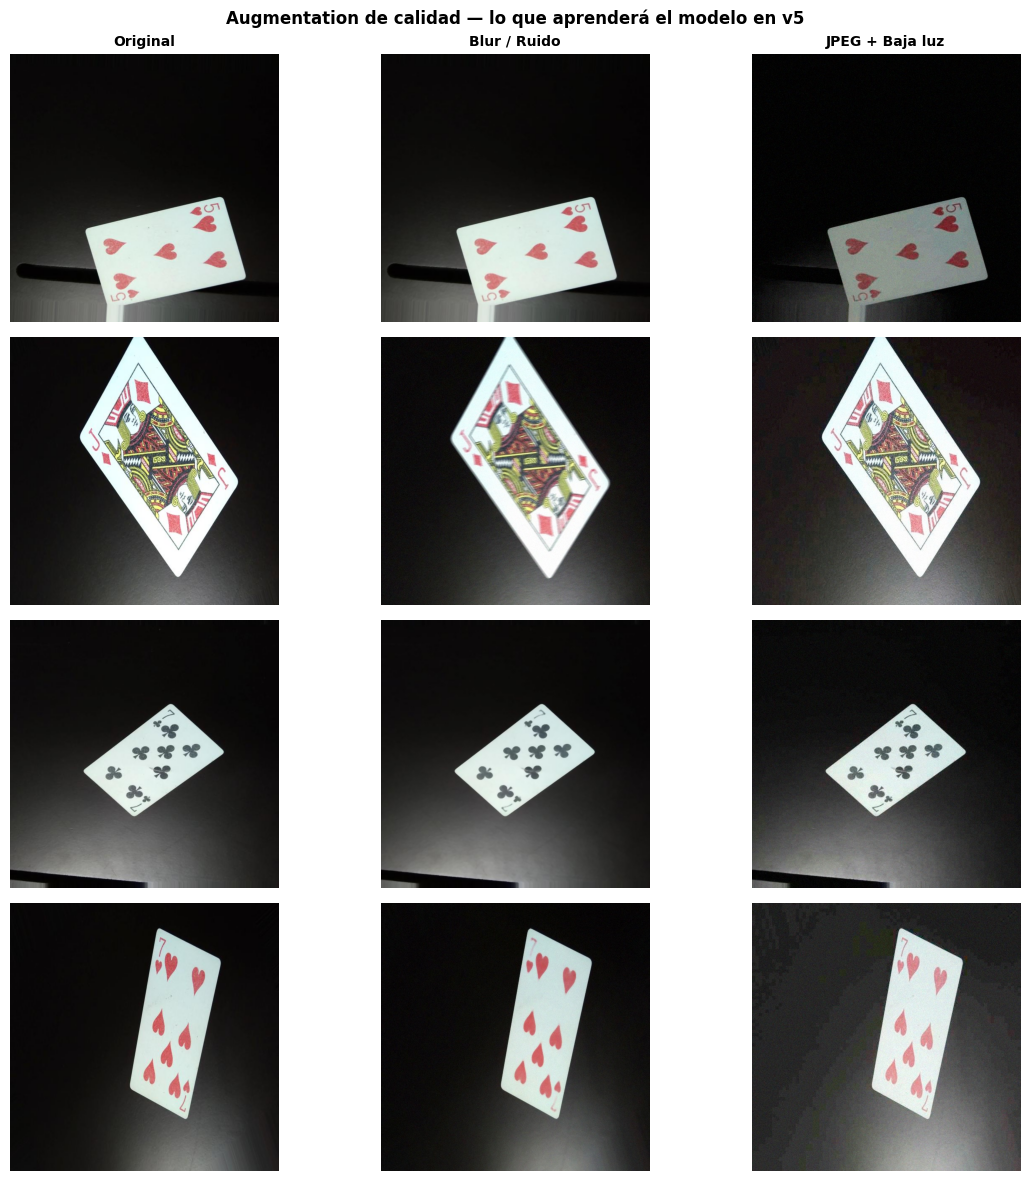

In [8]:
import matplotlib.pyplot as plt
import random

random.seed(SEED)

img_dir = DATASET_DIR / "train" / "images"
orig_imgs = [p for p in img_dir.glob("*.*")
             if not any(t in p.stem for t in ["_aug_blur", "_aug_quality"])]
samples = random.sample(orig_imgs, min(4, len(orig_imgs)))

suffixes = ["", "_aug_blur", "_aug_quality"]
titles   = ["Original", "Blur / Ruido", "JPEG + Baja luz"]

fig, axes = plt.subplots(len(samples), 3, figsize=(12, len(samples) * 3))

for row, orig in enumerate(samples):
    for col, (suf, title) in enumerate(zip(suffixes, titles)):
        p = img_dir / f"{orig.stem}{suf}{orig.suffix}"
        ax = axes[row, col]
        if p.exists():
            img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.set_title(title if row == 0 else "", fontsize=10, fontweight="bold")
        else:
            ax.text(0.5, 0.5, "No generado", ha="center", va="center")
        ax.axis("off")

plt.suptitle("Augmentation de calidad — lo que aprenderá el modelo en v5",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Configurar MLflow

In [9]:
from ultralytics import settings as yolo_settings

yolo_settings.update({"mlflow": True})

print(f"YOLO mlflow activo  : {yolo_settings.get('mlflow')}")
print(f"MLflow URI          : {os.environ['MLFLOW_TRACKING_URI']}")
print(f"MLflow experiment   : {os.environ['MLFLOW_EXPERIMENT_NAME']}")

YOLO mlflow activo  : True
MLflow URI          : sqlite:////home/dmore/code/Máster IA/01.-MASTER COURSES/12.- MLOPS Y AI BI/mlops_env/mlflow.db
MLflow experiment   : blackjackvai-v5


## 9. Entrenamiento

### Estrategia v5

| Aspecto | v4 | v5 |
|---------|----|----|  
| Base | best.pt v3 | **best.pt v4** |
| Datos train | ~2 574 imágenes | **~7 700 imágenes** (x3 con degradadas) |
| Calidad imagen | No | **Blur, ruido, JPEG, baja luz** |
| Distancia | scale=0.85 | scale=0.85 (mantenido) |
| Epochs | 120 | 80 (base ya muy buena) |
| lr0 | auto (0.000172) | **0.0005** (más fino aún) |

### Albumentations en YOLO
Con albumentations instalado, YOLO aplica automáticamente en cada batch:
`Blur`, `MedianBlur`, `ToGray`, `CLAHE`, `RandomBrightnessContrast`, `ImageCompression`.
Combinado con las imágenes pre-degradadas del dataset, el modelo verá degradación
de calidad en prácticamente todos los batches.

In [10]:
from ultralytics import YOLO

resuming = RESUME and LAST_PT.exists()

if resuming:
    print(f"Reanudando desde: {LAST_PT}")
    model = YOLO(str(LAST_PT))
else:
    print(f"Fine-tuning desde: {MODEL_BASE}")
    model = YOLO(MODEL_BASE)

train_kwargs = dict(
    data         = str(DATA_YAML),
    task         = "segment",
    epochs       = EPOCHS,
    imgsz        = IMGSZ,
    batch        = BATCH,
    device       = DEVICE,
    workers      = 4,
    seed         = SEED,
    pretrained   = True,
    amp          = True,
    cache        = False,
    cos_lr       = True,
    lr0          = 0.0005,      # más conservador que v4 — ajuste muy fino
    lrf          = 0.01,
    warmup_epochs= 2,
    patience     = PATIENCE,
    save_period  = SAVE_PERIOD,
    plots        = True,
    save         = True,
    project      = str(WORKDIR / "runs"),
    name         = RUN_NAME,
    exist_ok     = True,
    rect         = False,
    # ── Augmentation geométrico (igual que v4) ──────────────────────
    hsv_h        = 0.02,
    hsv_s        = 0.90,
    hsv_v        = 0.60,
    degrees      = 20.0,
    translate    = 0.20,
    scale        = 0.85,
    shear        = 8.0,
    perspective  = 0.001,
    flipud       = 0.25,
    fliplr       = 0.50,
    mosaic       = 1.0,
    mixup        = 0.25,
    copy_paste   = 0.60,
    erasing      = 0.50,
    close_mosaic = 15,
    overlap_mask = True,
    mask_ratio   = 4,
)

if resuming:
    results = model.train(resume=True)
else:
    results = model.train(**train_kwargs)

RUN_DIR_FINAL = Path(model.trainer.save_dir)
BEST_PT_FINAL = RUN_DIR_FINAL / "weights" / "best.pt"
LAST_PT_FINAL = RUN_DIR_FINAL / "weights" / "last.pt"

print(f"\nEntrenamiento completado.")
print(f"best.pt → {BEST_PT_FINAL}")

Fine-tuning desde: models/best.pt
New https://pypi.org/project/ultralytics/8.4.46 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.45 🚀 Python-3.11.14 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.6, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/dmore/code/Máster IA/01.-MASTER COURSES/10.- VISIÓN ARTIFICIAL AVANZADA/blackjack-VAI/BlackjackVAI-4/data.yaml, degrees=20.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.5, exist_ok=True, fliplr=0.5, flipud=0.25, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.9, hsv_v=0.6, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None

2026/05/04 21:39:17 INFO mlflow.tracking.fluent: Experiment with name 'blackjackvai-v5' does not exist. Creating a new experiment.


MLflow: logging run_id(5873e95c98ec4399a69d218190224a37) to sqlite:////home/dmore/code/Máster IA/01.-MASTER COURSES/12.- MLOPS Y AI BI/mlops_env/mlflow.db
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to /home/dmore/code/Máster IA/01.-MASTER COURSES/10.- VISIÓN ARTIFICIAL AVANZADA/blackjack-VAI/training_runs/runs/yolo8m_seg_v5
Starting training for 80 epochs...

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
       1/80      3.95G     0.2691     0.4423      0.477     0.8729          0         11        640: 100% ━━━━━━━━━━━━ 966/966 3.8it/s 4:17<0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 41/41 4.3it/s 9.6s0.2s
                   all        644        718      0.979      0.976      0.984      0.976      0.977      0.974      0.981      0.977

   

/home/dmore/code/Máster IA/01.-MASTER COURSES/12.- MLOPS Y AI BI/mlops_env/.venv/lib/python3.11/site-packages/ultralytics/data/augment.py:1183: RuntimeWarning: divide by zero encountered in divide
  xy = xy[:, :2] / xy[:, 2:3]


      29/80      3.98G     0.2759     0.4441     0.4463     0.8766          0          3        640: 100% ━━━━━━━━━━━━ 966/966 3.8it/s 4:12<0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 41/41 4.4it/s 9.4s0.2s
                   all        644        718      0.973      0.979      0.986      0.978      0.971      0.977      0.982      0.977

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
      30/80      3.98G     0.2815       0.45     0.4572     0.8821          0          6        640: 100% ━━━━━━━━━━━━ 966/966 3.8it/s 4:11<0.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 41/41 4.3it/s 9.5s0.2s
                   all        644        718      0.973      0.982      0.986      0.977      0.971       0.98      0.982     

/home/dmore/code/Máster IA/01.-MASTER COURSES/12.- MLOPS Y AI BI/mlops_env/.venv/lib/python3.11/site-packages/ultralytics/data/augment.py:1183: RuntimeWarning: divide by zero encountered in divide
  xy = xy[:, :2] / xy[:, 2:3]


      42/80      3.98G     0.2671       0.43     0.4112     0.8752          0          8        640: 100% ━━━━━━━━━━━━ 966/966 3.8it/s 4:12<0.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 41/41 4.3it/s 9.5s0.2s
                   all        644        718       0.98      0.984      0.986      0.978      0.978      0.982      0.983      0.979

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
      43/80      3.98G     0.2633     0.4263     0.4007     0.8691          0         10        640: 100% ━━━━━━━━━━━━ 966/966 3.8it/s 4:11<0.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 41/41 4.4it/s 9.2s0.2s
                   all        644        718      0.979      0.984      0.986      0.978      0.977      0.982      0.983     

## 10. Curvas de entrenamiento

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

results_csv = RUN_DIR_FINAL / "results.csv"
if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    for col, lbl in [("train/box_loss", "train"), ("val/box_loss", "val")]:
        if col in df.columns: axes[0].plot(df["epoch"], df[col], label=lbl)
    axes[0].set_title("Box Loss"); axes[0].legend()

    for col, lbl in [("metrics/mAP50(B)", "mAP50"), ("metrics/mAP50-95(B)", "mAP50-95")]:
        if col in df.columns: axes[1].plot(df["epoch"], df[col], label=lbl)
    axes[1].set_title("mAP — Box"); axes[1].legend()

    for col, lbl in [("metrics/mAP50(M)", "mAP50"), ("metrics/mAP50-95(M)", "mAP50-95")]:
        if col in df.columns: axes[2].plot(df["epoch"], df[col], label=lbl)
    axes[2].set_title("mAP — Máscara"); axes[2].legend()

    plt.suptitle("Curvas de entrenamiento — BlackjackVAI V5", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("results.csv no encontrado.")

NameError: name 'RUN_DIR_FINAL' is not defined

## 11. Evaluación sobre validación + log MLflow

In [3]:
import mlflow
import re
from ultralytics import YOLO
from datetime import datetime

def sanitize(key):
    return re.sub(r'[^a-zA-Z0-9_\-\. :/]', '_', key)

model = YOLO(str(BEST_PT_FINAL))

m = model.val(
    data=str(DATA_YAML),
    split="val",
    imgsz=IMGSZ,
    conf=0.5,
    iou=0.45,
    plots=True,
    save_json=True,
)

print(f"\nmAP50      (box) : {m.box.map50:.4f}")
print(f"mAP50-95   (box) : {m.box.map:.4f}")
print(f"mAP50      (mask): {m.seg.map50:.4f}")
print(f"mAP50-95   (mask): {m.seg.map:.4f}")

mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
mlflow.set_experiment(MLFLOW_EXPERIMENT)

with mlflow.start_run(run_name=f"val_eval_{datetime.now():%Y%m%d_%H%M}"):
    mlflow.log_metrics({
        "val/mAP50_box":     m.box.map50,
        "val/mAP50-95_box":  m.box.map,
        "val/mAP50_mask":    m.seg.map50,
        "val/mAP50-95_mask": m.seg.map,
        "val/precision":     m.box.mp,
        "val/recall":        m.box.mr,
    })

    for k, v in m.results_dict.items():
        try:
            mlflow.log_metric(f"val_{sanitize(k)}", float(v))
        except (TypeError, ValueError):
            pass

    mlflow.log_params({
        "base_model":       "best_v4.pt",
        "scale":            0.85,
        "copy_paste":       0.60,
        "erasing":          0.50,
        "quality_aug":      "blur+noise+jpeg+lowlight",
        "train_images":     "x3 (orig+blur+quality)",
        "imgsz_train":      IMGSZ,
        "imgsz_infer":      1280,
        "split":            "80/20 (sin test)",
        "dataset_ver":      4,
        "epochs":           EPOCHS,
        "lr0":              0.0005,
    })

    mlflow.log_artifact(str(BEST_PT_FINAL), artifact_path="model")
    mlflow.log_artifacts(str(RUN_DIR_FINAL), artifact_path="train_artifacts")

    mlflow.set_tags({
        "stage":         "val_evaluation",
        "dataset":       "BlackjackVAI-V4-augmented",
        "classes":       54,
        "backbone":      "yolov8m-seg",
        "aug_strategy":  "distance+quality_degradation",
    })

    print("\nLoggeado en MLflow ✓")

/home/dmore/code/Máster IA/01.-MASTER COURSES/12.- MLOPS Y AI BI/mlops_env/.venv/lib/python3.11/site-packages/pydantic/_internal/_fields.py:160: UserWarning: Field "model_name" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
/home/dmore/code/Máster IA/01.-MASTER COURSES/12.- MLOPS Y AI BI/mlops_env/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'BEST_PT_FINAL' is not defined

## 12. Grid de predicciones sobre val

In [ ]:
import cv2, random
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

random.seed(SEED)
pred_model = YOLO(str(BEST_PT_FINAL))

def pred_grid(img_dir: Path, title: str, n=9, conf=0.25):
    imgs  = [p for p in img_dir.rglob("*.*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}]
    samp  = random.sample(imgs, min(n, len(imgs)))
    preds = pred_model.predict(source=[str(p) for p in samp], imgsz=IMGSZ, conf=conf, verbose=False)
    cols  = 3; rows = (len(preds) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    axes = np.array(axes).flatten()
    for i, res in enumerate(preds):
        ann  = cv2.cvtColor(res.plot(line_width=2), cv2.COLOR_BGR2RGB)
        dets = len(res.boxes) if res.boxes is not None else 0
        axes[i].imshow(ann)
        axes[i].set_title(f"{Path(res.path).name}  |  {dets} det.", fontsize=8)
        axes[i].axis("off")
    for j in range(len(preds), len(axes)): axes[j].axis("off")
    plt.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()

pred_grid(DATASET_DIR / "val" / "images", "Predicciones — VAL · conf ≥ 0.25", n=9)

## 13. Test de robustez — predicciones sobre imágenes degradadas

Aplica las mismas degradaciones de calidad sobre imágenes de **validación** (que el modelo no vio en train)
y evalúa si sigue detectando correctamente. Es la prueba definitiva de robustez.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
import random
from ultralytics import YOLO

random.seed(SEED)
rob_model = YOLO(str(BEST_PT_FINAL))

degradations = [
    ("Original",         lambda img: img),
    ("Blur fuerte",      lambda img: A.GaussianBlur(blur_limit=(7, 11), p=1)(image=img)["image"]),
    ("Motion blur",      lambda img: A.MotionBlur(blur_limit=13, p=1)(image=img)["image"]),
    ("JPEG q=15",        lambda img: A.ImageCompression(quality_lower=10, quality_upper=20, p=1)(image=img)["image"]),
    ("Baja luz",         lambda img: A.RandomBrightnessContrast(brightness_limit=(-0.6, -0.4), contrast_limit=(-0.4, -0.2), p=1)(image=img)["image"]),
    ("Ruido + blur",     lambda img: A.Compose([A.GaussNoise(var_limit=(50, 120), p=1), A.GaussianBlur(blur_limit=(3, 7), p=1)])(image=img)["image"]),
]

val_imgs = [p for p in (DATASET_DIR / "val" / "images").glob("*.*")]
samples  = random.sample(val_imgs, min(3, len(val_imgs)))

fig, axes = plt.subplots(len(samples), len(degradations),
                         figsize=(len(degradations) * 3, len(samples) * 3))

for row, img_path in enumerate(samples):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    for col, (title, fn) in enumerate(degradations):
        deg_rgb = fn(img_rgb.copy())
        deg_bgr = cv2.cvtColor(deg_rgb, cv2.COLOR_RGB2BGR)

        res  = rob_model.predict(source=deg_bgr, imgsz=1280, conf=0.35, verbose=False)[0]
        ann  = cv2.cvtColor(res.plot(line_width=1), cv2.COLOR_BGR2RGB)
        dets = len(res.boxes) if res.boxes is not None else 0

        ax = axes[row, col]
        ax.imshow(ann)
        ax.set_title(f"{title}\n{dets} det.",
                     fontsize=8,
                     color="green" if dets > 0 else "red",
                     fontweight="bold" if row == 0 else "normal")
        ax.axis("off")

plt.suptitle("Test de robustez — detección bajo degradación de imagen (val set)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 14. Exportar modelo final a `models/`

In [ ]:
import shutil
from datetime import datetime

ts   = datetime.now().strftime("%Y%m%d_%H%M")
dest = MODELS_DIR / f"best_v5_{ts}.pt"
shutil.copy2(str(BEST_PT_FINAL), str(dest))

link = MODELS_DIR / "best.pt"
if link.exists() or link.is_symlink():
    link.unlink()
link.symlink_to(dest.name)

print(f"Modelo guardado: {dest}")
print(f"Enlace activo  : {link} → {dest.name}")
print("\nContenido de models/:")
for f in sorted(MODELS_DIR.iterdir()):
    size = f.stat().st_size / 1e6 if f.is_file() else 0
    print(f"  {f.name}  ({size:.1f} MB)")

## 15. Test con webcam local

`imgsz=1280` para aprovechar la resolución nativa de la webcam. Pulsa **Q** para salir.

In [ ]:
import cv2
from ultralytics import YOLO

WEBCAM_INDEX = 0
CONF_THRESH  = 0.35
INFER_IMGSZ  = 1280

webcam_model = YOLO(str(MODELS_DIR / "best.pt"))

cap = cv2.VideoCapture(WEBCAM_INDEX)
if not cap.isOpened():
    raise RuntimeError(f"No se puede abrir la cámara {WEBCAM_INDEX}")

print(f"Webcam abierta — imgsz={INFER_IMGSZ} — pulsa Q para salir")
while True:
    ret, frame = cap.read()
    if not ret:
        break
    results  = webcam_model.predict(source=frame, imgsz=INFER_IMGSZ,
                                    conf=CONF_THRESH, verbose=False)
    annotated = results[0].plot(line_width=2)
    cv2.imshow("BlackjackVAI v5", annotated)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()
print("Webcam cerrada.")